In [7]:
import sys
dice_path = "/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X"
sys.path.insert(0, dice_path)

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.stats import ks_2samp, wasserstein_distance, chi2_contingency
import matplotlib.pyplot as plt
from alibi_detect.cd import MMDDrift
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
import os
import torch

from dice_ml_x.utils import helpers
from dice_ml_x.benchmarking import Benchmarking

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
all_datasets = {
    "compas-recidivism": {
        "data": helpers.load_compas_dataset(),
        "target": "twoyearrecid"
    },
    "adult-income": {
        "data": helpers.load_adult_income_dataset(),
        "target": "income"
    },
    "lending-club": {
        "data": helpers.load_lending_club_dataset(),
        "target": "loan_status"
    },
    "german-credit": {
        "data": helpers.load_german_credit_dataset(),
        "target": "credit_risk"
    }
}

file_names = os.listdir('cfe_datasets')
keys = [(f_name.split('_')[0], f_name.split('_')[1]) for f_name in file_names]
target_names = {'lending-club': 'loan_status', 'compas-recidivism': 'twoyearrecid',
                'adult-income': 'income', 'german-credit': 'credit_risk'}
cfe_datasets = {}
for key, f_name in zip(keys, file_names):
    new_key = key + (target_names[key[0]],)
    cfe_datasets[new_key] = pd.read_csv(os.path.join('cfe_datasets', f_name))

for (df_name, backend_name, target_name), cfe_dataset in cfe_datasets.items():
    cfe_dataset[target_name] = np.where(cfe_dataset[target_name] < 0.5, 0, 1)

Using device: mps
------------------------------  Computing the tests for the dataset compas-recidivism on counterfactual dataset compas-recidivism using backend TF2  ------------------------------


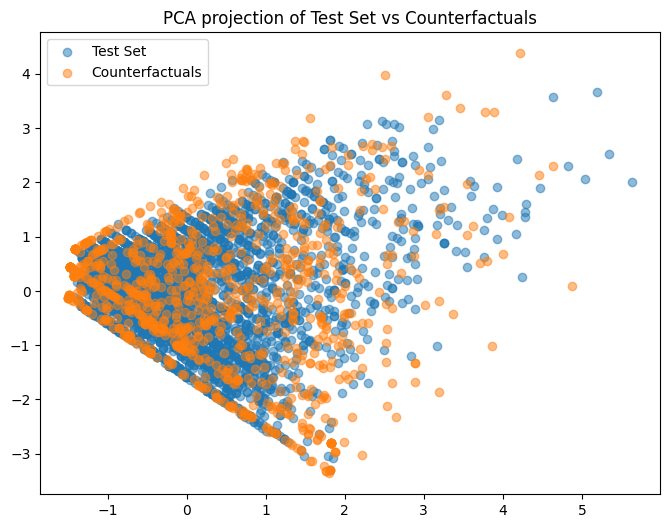

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
age                  | KS p = 0.0000 | Wasserstein = 4.9118
priors_count         | KS p = 0.0000 | Wasserstein = 1.8972

Chi-square test for categorical features:
sex                  | p = 0.0864
race                 | p = 0.8975
c_charge_degree      | p = 0.6646

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset compas-recidivism on counterfactual dataset compas-recidivism using backend sklearn  ------------------------------


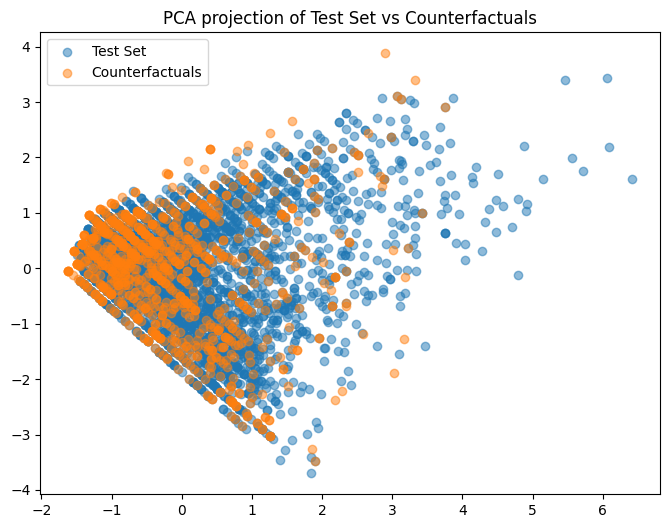

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
age                  | KS p = 0.0000 | Wasserstein = 1.1292
priors_count         | KS p = 0.1089 | Wasserstein = 0.5674

Chi-square test for categorical features:
sex                  | p = 0.9269
race                 | p = 0.2140
c_charge_degree      | p = 0.5638

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset compas-recidivism on counterfactual dataset compas-recidivism using backend PYT  ------------------------------


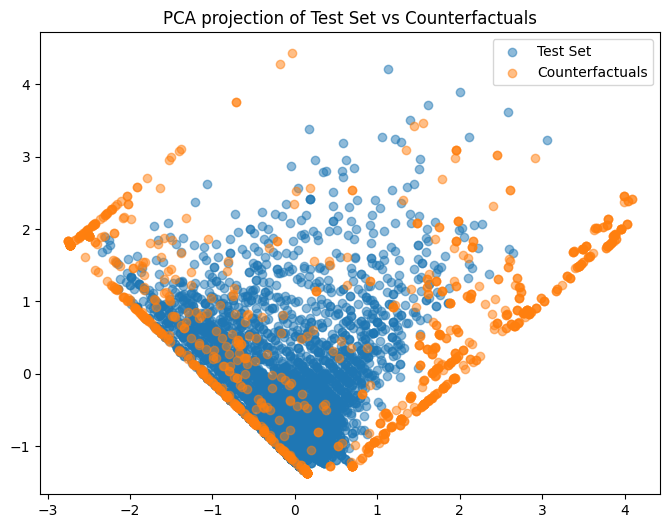

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
age                  | KS p = 0.0000 | Wasserstein = 8.8680
priors_count         | KS p = 0.0000 | Wasserstein = 6.5191

Chi-square test for categorical features:
sex                  | p = 0.0153
race                 | p = 0.8884
c_charge_degree      | p = 0.6434

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset adult-income on counterfactual dataset adult-income using backend PYT  ------------------------------


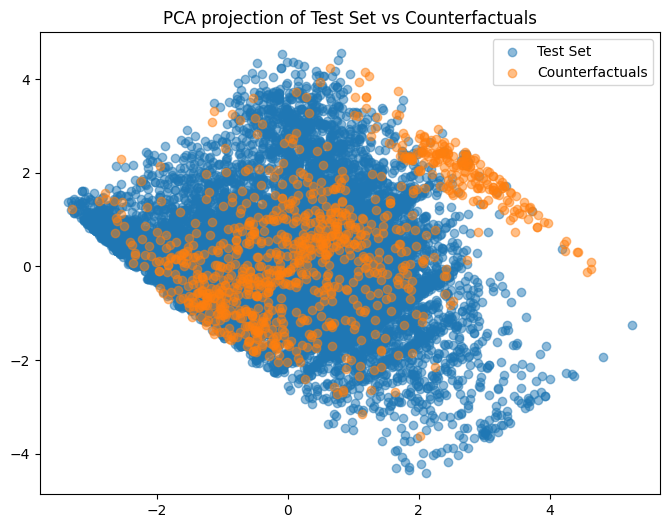

KS test and Wasserstein distance for numeric features:


No GPU detected, fall back on CPU.


age                  | KS p = 0.0000 | Wasserstein = 11.1687
hours_per_week       | KS p = 0.0000 | Wasserstein = 2.8177

Chi-square test for categorical features:
workclass            | p = 0.2549
education            | p = 0.7398
marital_status       | p = 0.8321
occupation           | p = 0.6479
race                 | p = 1.0000
gender               | p = 0.3084

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset adult-income on counterfactual dataset adult-income using backend TF2  ------------------------------


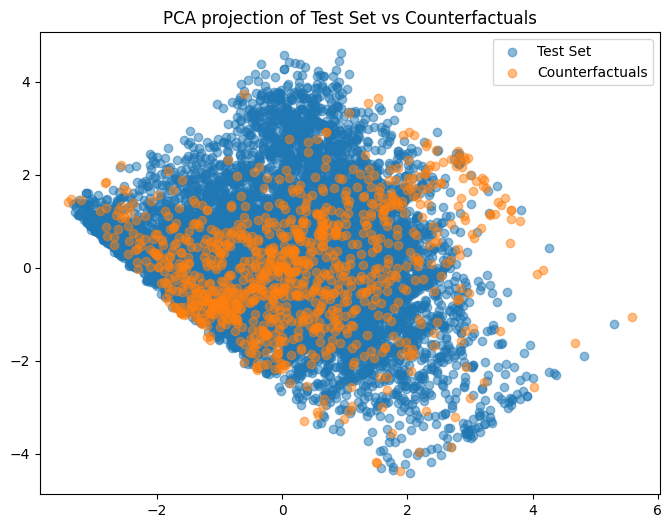

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
age                  | KS p = 0.0000 | Wasserstein = 5.1146
hours_per_week       | KS p = 0.0000 | Wasserstein = 4.3212

Chi-square test for categorical features:
workclass            | p = 0.5978
education            | p = 0.9652
marital_status       | p = 0.8961
occupation           | p = 0.8959
race                 | p = 0.1553
gender               | p = 0.0013

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset adult-income on counterfactual dataset adult-income using backend sklearn  ------------------------------


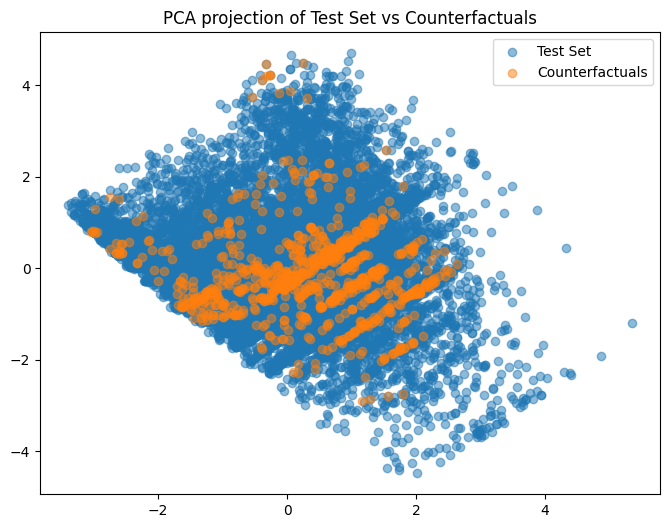

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
age                  | KS p = 0.0000 | Wasserstein = 2.0899
hours_per_week       | KS p = 0.0000 | Wasserstein = 3.0534

Chi-square test for categorical features:
workclass            | p = 0.5762
education            | p = 0.3118
marital_status       | p = 0.4758
occupation           | p = 0.0675
race                 | p = 0.5235
gender               | p = 0.9842

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset lending-club on counterfactual dataset lending-club using backend PYT  ------------------------------


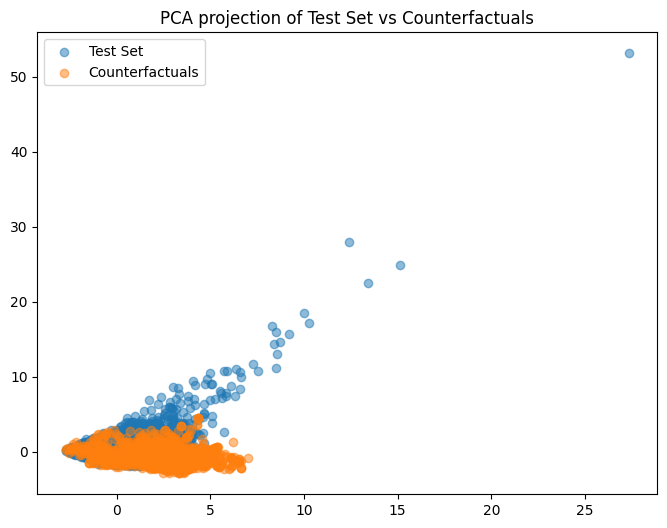

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
employment_years     | KS p = 0.0000 | Wasserstein = 3.2542
num_open_credit_acc  | KS p = 0.0000 | Wasserstein = 8.5471
annual_income        | KS p = 0.0000 | Wasserstein = 32786.5228
credit_history       | KS p = 0.0000 | Wasserstein = 12.4015

Chi-square test for categorical features:
loan_grade           | p = 0.8376
purpose              | p = 0.7462
home                 | p = 0.6050
addr_state           | p = 0.9371

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset lending-club on counterfactual dataset lending-club using backend TF2  ------------------------------


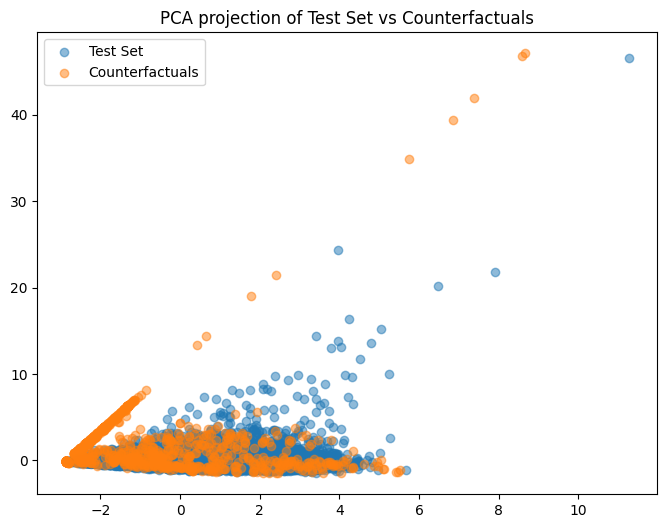

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
employment_years     | KS p = 0.0000 | Wasserstein = 2.8386
num_open_credit_acc  | KS p = 0.0000 | Wasserstein = 3.8239
annual_income        | KS p = 0.0000 | Wasserstein = 120332.5797
credit_history       | KS p = 0.0000 | Wasserstein = 5.4226

Chi-square test for categorical features:
loan_grade           | p = 0.4439
purpose              | p = 0.7471
home                 | p = 0.8348
addr_state           | p = 0.9975

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset lending-club on counterfactual dataset lending-club using backend sklearn  ------------------------------


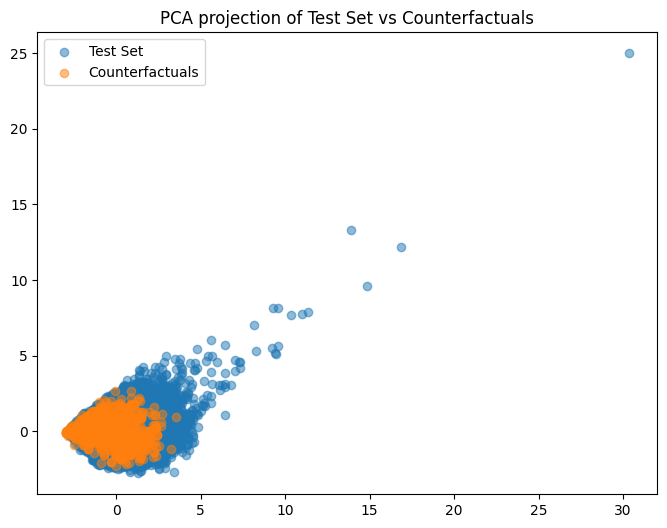

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
employment_years     | KS p = 0.0000 | Wasserstein = 0.8334
num_open_credit_acc  | KS p = 0.0000 | Wasserstein = 1.3170
annual_income        | KS p = 0.0000 | Wasserstein = 6862.5005
credit_history       | KS p = 0.0000 | Wasserstein = 2.1476

Chi-square test for categorical features:
loan_grade           | p = 0.0739
purpose              | p = 0.9587
home                 | p = 0.1321
addr_state           | p = 0.5888

MMD Drift Detection:
Drift Detected: Yes | p-value = 0.0000
------------------------------  Computing the tests for the dataset german-credit on counterfactual dataset german-credit using backend sklearn  ------------------------------


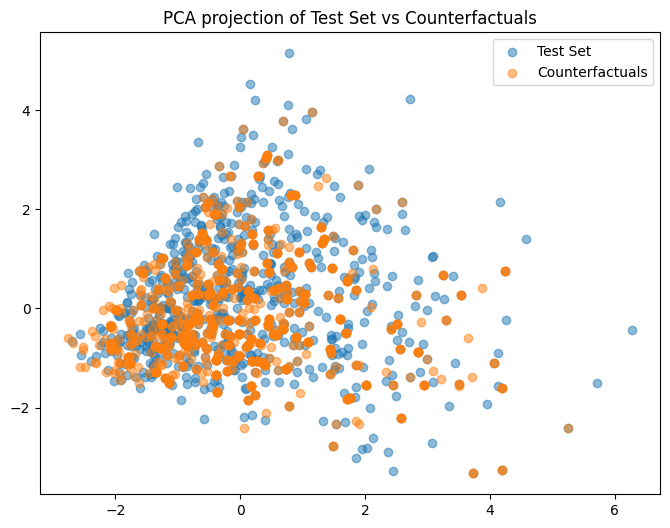

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
duration_in_month    | KS p = 0.0000 | Wasserstein = 2.1070
credit_amount        | KS p = 0.0286 | Wasserstein = 251.2577
installment_rate_in_percentage_of_disposable_income | KS p = 0.0001 | Wasserstein = 0.2187
present_residence_since | KS p = 0.0184 | Wasserstein = 0.1160
age_in_years         | KS p = 0.0001 | Wasserstein = 1.2567
number_of_existing_credits_at_this_bank | KS p = 0.0000 | Wasserstein = 0.1435
number_of_people_being_liable_to_provide_maintenance_for | KS p = 0.0000 | Wasserstein = 0.1210

Chi-square test for categorical features:
status_of_existing_checking_account | p = 0.6772
credit_history       | p = 0.9197
purpose              | p = 0.2983
savings_account_bonds | p = 0.0224
present_employment_since | p = 0.5114
personal_status_and_sex | p = 0.7189
other_debtors_guarantors | p = 0.8729
property             | p = 0.8300
other_installment_plans | p = 0.6127
housing              | p = 0.6475
job                  

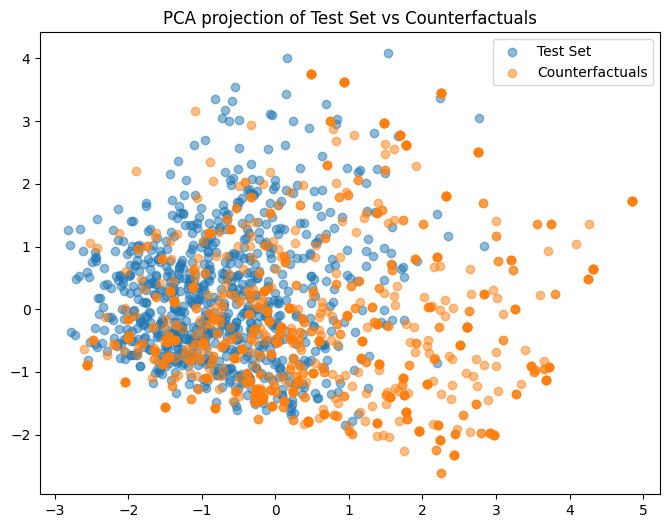

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
duration_in_month    | KS p = 0.0000 | Wasserstein = 6.0055
credit_amount        | KS p = 0.0000 | Wasserstein = 974.2328
installment_rate_in_percentage_of_disposable_income | KS p = 0.0000 | Wasserstein = 0.5117
present_residence_since | KS p = 0.0000 | Wasserstein = 0.5420
age_in_years         | KS p = 0.0000 | Wasserstein = 6.6628
number_of_existing_credits_at_this_bank | KS p = 0.0000 | Wasserstein = 0.8135
number_of_people_being_liable_to_provide_maintenance_for | KS p = 0.0000 | Wasserstein = 0.3290

Chi-square test for categorical features:
status_of_existing_checking_account | p = 0.3812
credit_history       | p = 0.3297
purpose              | p = 0.5379
savings_account_bonds | p = 0.3701
present_employment_since | p = 0.2531
personal_status_and_sex | p = 0.1989
other_debtors_guarantors | p = 0.9659
property             | p = 0.5036
other_installment_plans | p = 0.5038
housing              | p = 0.0110
job                  

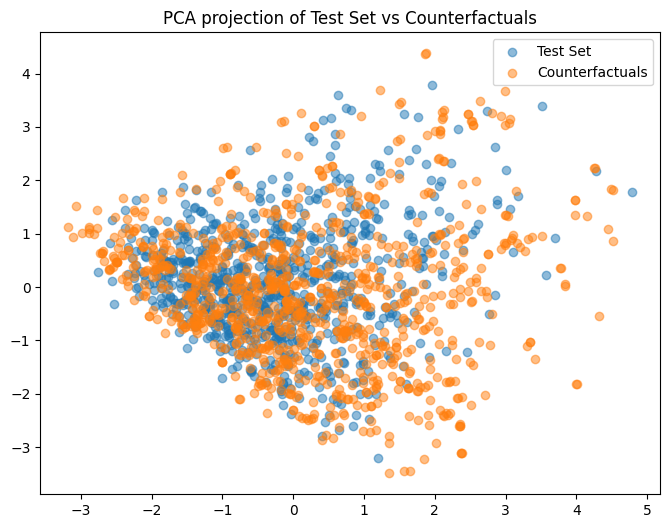

No GPU detected, fall back on CPU.


KS test and Wasserstein distance for numeric features:
duration_in_month    | KS p = 0.0001 | Wasserstein = 2.1905
credit_amount        | KS p = 0.0000 | Wasserstein = 755.5668
installment_rate_in_percentage_of_disposable_income | KS p = 0.1129 | Wasserstein = 0.0817
present_residence_since | KS p = 0.0269 | Wasserstein = 0.1380
age_in_years         | KS p = 0.0000 | Wasserstein = 4.3143
number_of_existing_credits_at_this_bank | KS p = 0.0000 | Wasserstein = 0.4565
number_of_people_being_liable_to_provide_maintenance_for | KS p = 0.5301 | Wasserstein = 0.0380

Chi-square test for categorical features:
status_of_existing_checking_account | p = 0.1438
credit_history       | p = 0.5473
purpose              | p = 0.0605
savings_account_bonds | p = 0.9054
present_employment_since | p = 0.8523
personal_status_and_sex | p = 0.6609
other_debtors_guarantors | p = 0.8620
property             | p = 0.9032
other_installment_plans | p = 0.4065
housing              | p = 0.5587
job                  

In [21]:


warnings.filterwarnings("ignore")

print(f"Using device: {'mps' if torch.backends.mps.is_available() else 'cpu'}")

def preprocess_and_compare_distributions(X_test: pd.DataFrame, X_cf: pd.DataFrame, ds_name, cf_ds_name,
                                         backend_name, categorical_cols: list = None):
    
    print("-" * 30, f" Computing the tests for the dataset {ds_name} on counterfactual dataset {cf_ds_name} using backend {backend_name} ", "-" * 30)
    if categorical_cols is None:
        categorical_cols = X_test.select_dtypes(include=['object', 'category']).columns.tolist()


    numeric_cols = [col for col in X_test.columns if col not in categorical_cols]


    X_all = pd.concat([X_test, X_cf], axis=0).reset_index(drop=True)


    encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
    X_cat = encoder.fit_transform(X_all[categorical_cols])
    cat_feature_names = encoder.get_feature_names_out(categorical_cols)
    X_cat_df = pd.DataFrame(X_cat, columns=cat_feature_names)


    scaler = StandardScaler()
    X_num = scaler.fit_transform(X_all[numeric_cols])
    X_num_df = pd.DataFrame(X_num, columns=numeric_cols)


    X_processed = pd.concat([X_num_df.reset_index(drop=True), X_cat_df.reset_index(drop=True)], axis=1)
    X_test_proc = X_processed.iloc[:len(X_test)]
    X_cf_proc = X_processed.iloc[len(X_test):]


    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_processed)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:len(X_test), 0], X_pca[:len(X_test), 1], label="Test Set", alpha=0.5)
    plt.scatter(X_pca[len(X_test):, 0], X_pca[len(X_test):, 1], label="Counterfactuals", alpha=0.5)
    plt.legend()
    plt.title("PCA projection of Test Set vs Counterfactuals")
    plt.show()


    print("KS test and Wasserstein distance for numeric features:")
    for col in numeric_cols:
        ks_stat, ks_p = ks_2samp(X_test[col], X_cf[col])
        w_dist = wasserstein_distance(X_test[col], X_cf[col])
        print(f"{col:<20} | KS p = {ks_p:.4f} | Wasserstein = {w_dist:.4f}")


    print("\nChi-square test for categorical features:")
    for col in categorical_cols:
        observed = pd.crosstab(X_test[col], X_cf[col])
        if observed.shape[0] > 1 and observed.shape[1] > 1:
            chi2, p, _, _ = chi2_contingency(observed)
            print(f"{col:<20} | p = {p:.4f}")
        else:
            print(f"{col:<20} | Not enough variability for chi-square test")


    print("\nMMD Drift Detection:")
    mmd = MMDDrift(X_test_proc.values, p_val=0.05, backend='pytorch')
    preds = mmd.predict(X_cf_proc.values)
    print(f"Drift Detected: {'Yes' if preds['data']['is_drift'] else 'No'} | p-value = {preds['data']['p_val']:.4f}")


for ds_name, info in all_datasets.items():
    ds = info["data"]
    target_col = info["target"]
    
    train_df, test_df, y_train, y_test = train_test_split(
        ds, ds[target_col], test_size=0.2, random_state=42, shuffle=True, stratify=ds[target_col]
    )

    for (cf_ds_name, backend_name, cf_target_col), cf_df in cfe_datasets.items():
        if cf_ds_name != ds_name:
            continue

        X_test = train_df.drop(columns=[target_col])
        X_cf = cf_df.drop(columns=[cf_target_col])

        preprocess_and_compare_distributions(X_test, X_cf, ds_name, cf_ds_name, backend_name, categorical_cols=X_test.select_dtypes(include=['object', 'category']).columns.tolist())
